In [1]:
import slangpy as spy
import numpy as np
import quaternion
import pathlib
import matplotlib.pyplot as plt
from pyglm import glm

from bvhgs.camera import Camera
from bvhgs.renderer import Renderer
from bvhgs.gaussian import GaussianCloud

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


# Create Scene

In [2]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"))
len(gaussians)

104692

In [3]:
cam_rot_mat = np.array([
    [
        0.786188006401062,
        -0.01644204743206501,
        -0.6177687048912048
    ],
    [
        -0.028784452006220818,
        0.9975867867469788,
        -0.06318280845880508
    ],
    [
        0.6173167824745178,
        0.0674557015299797,
        0.7838174700737
    ]

])
cam_rot = quaternion.from_rotation_matrix(cam_rot_mat)
cam_pos = np.array([
      0.6305696964263916,
      0.13185331225395203,
      -0.4680609107017517
])

In [4]:
camera = Camera(
    rotation=glm.quat(quaternion.as_float_array(cam_rot)),
    position=glm.vec3(cam_pos),
    sensor_size=glm.uvec2(979, 546),
    focal_length=580,
    near_plane=0.001,
    far_plane=100
)
camera.to_slang()

{'_rotation': [0.03458228334784508,
  -0.3269485533237457,
  -0.0032672490924596786,
  -0.9444036483764648],
 '_translation': vec3( -0.203009, -0.0895939, 0.764751 ),
 '_sensorSize': uvec2( 979, 546 ),
 '_focalLength': 580,
 '_nearPlane': 0.001,
 '_farPlane': 100}

# Render

In [5]:
renderer = Renderer(gaussians, camera)

In [6]:
renderer.render()

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



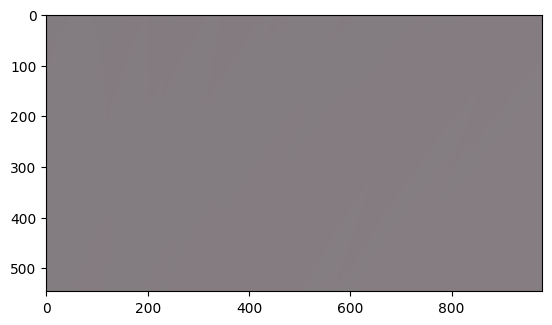

In [7]:
plt.imshow(renderer.render_target.to_numpy())

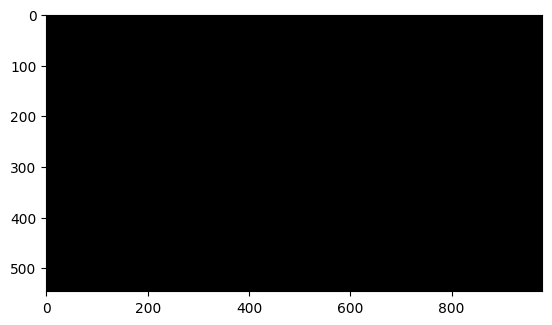

In [8]:
plt.imshow(renderer.depth_target.to_numpy())

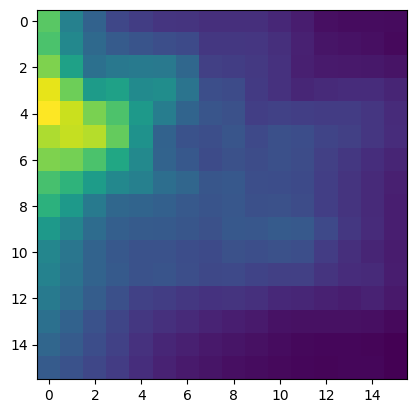

In [9]:
plt.imshow(renderer.tile_heat_map)